## Limpieza de datos - Eliminando duplicados

Verificar valores duplicados es extremandamente simple ya que tienen un comportamiento diferente en las **Series** y **DataFrames**. Como ejemplo diagamos que estamos lanzando una fiesta divertida y estamos invitando a embajadores de Europa. Pero solo se puede invitar un embajador por país. Esta es la lista original y como puedes ver UK y Germany tienen embajadores duplicados

![imagen.png](attachment:ddf923f9-a3d7-402d-90a8-f5064bad9ba3.png)

In [24]:
import numpy as np
import pandas as pd

In [16]:
ambassadors = pd.Series([
    'France',
    'United Kingdom',
    'United Kingdom',
    'Italy',
    'Germany',
    'Germany',
    'Germany',
], index = [
    'Gerard Araud',
    'Kim Derroch',
    'Peter Westmacott',
    'Armando Varricchio',
    'Peter Witting',
    'Peter Ammon',
    'Klaus Scharioth'
])

In [17]:
ambassadors

Gerard Araud                  France
Kim Derroch           United Kingdom
Peter Westmacott      United Kingdom
Armando Varricchio             Italy
Peter Witting                Germany
Peter Ammon                  Germany
Klaus Scharioth              Germany
dtype: object

Los métodos mas importantes para tratar con duplicados son **duplicated** (el cual te dice que valores estan duplicados) y **drop_duplicated** (que simplemente elimina los duplicados)

In [18]:
ambassadors.duplicated()

Gerard Araud          False
Kim Derroch           False
Peter Westmacott       True
Armando Varricchio    False
Peter Witting         False
Peter Ammon            True
Klaus Scharioth        True
dtype: bool

En este caso no considera Kim Derroch la primer instancia de UK o Peter Witting como duplicados. Por que por defecto los considera como la primera ocurrencia de valores no duplicados. Puedes cambiar este comportamiento con el parámetro *keep*

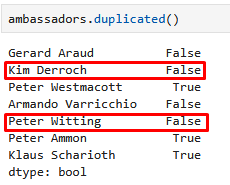

### Ejemplo con el parámetro keep = 'last'

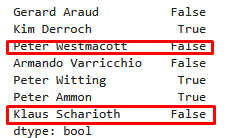

Lo mismo que en el anterior caso pero en este caso toma el último valor como no duplicado

In [19]:
ambassadors.duplicated(keep = 'last')

Gerard Araud          False
Kim Derroch            True
Peter Westmacott      False
Armando Varricchio    False
Peter Witting          True
Peter Ammon            True
Klaus Scharioth       False
dtype: bool

### Ejemplo con el parámetro keep = False

Con este parámetro se considera todos los valores como *Falsos*

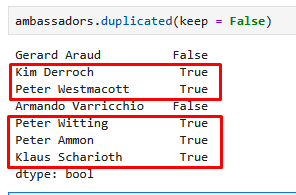

In [23]:
ambassadors.duplicated(keep = False)

Gerard Araud          False
Kim Derroch            True
Peter Westmacott       True
Armando Varricchio    False
Peter Witting          True
Peter Ammon            True
Klaus Scharioth        True
dtype: bool

## Eliminación de los duplicados

**drop_duplicates()** Por defecto solo mantiena la primera ocurrencia (de arriba a abajo) y elimina el resto

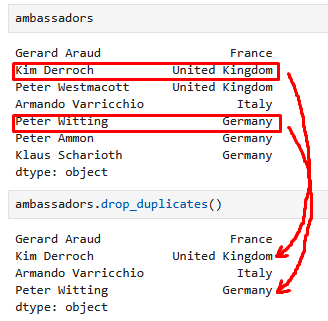

In [26]:
ambassadors

Gerard Araud                  France
Kim Derroch           United Kingdom
Peter Westmacott      United Kingdom
Armando Varricchio             Italy
Peter Witting                Germany
Peter Ammon                  Germany
Klaus Scharioth              Germany
dtype: object

In [27]:
ambassadors.drop_duplicates()

Gerard Araud                  France
Kim Derroch           United Kingdom
Armando Varricchio             Italy
Peter Witting                Germany
dtype: object

**drop_duplicates(keep = False)** Elimina todos los duplicados sin mantener ninguno

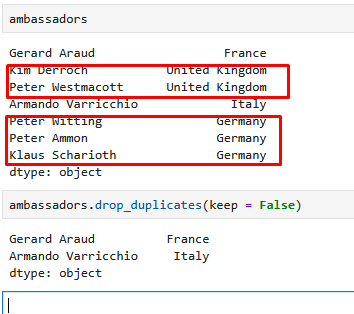

In [29]:
ambassadors

Gerard Araud                  France
Kim Derroch           United Kingdom
Peter Westmacott      United Kingdom
Armando Varricchio             Italy
Peter Witting                Germany
Peter Ammon                  Germany
Klaus Scharioth              Germany
dtype: object

In [30]:
ambassadors.drop_duplicates(keep = False)

Gerard Araud          France
Armando Varricchio     Italy
dtype: object

**drop_duplicates(keep = 'last')** Mantiene la última ocurrencia

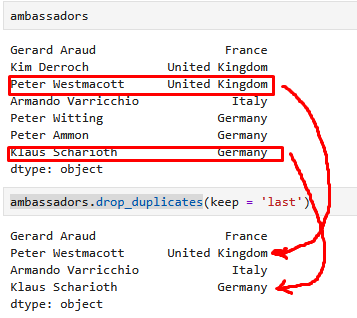

In [33]:
ambassadors

Gerard Araud                  France
Kim Derroch           United Kingdom
Peter Westmacott      United Kingdom
Armando Varricchio             Italy
Peter Witting                Germany
Peter Ammon                  Germany
Klaus Scharioth              Germany
dtype: object

In [31]:
ambassadors.drop_duplicates(keep = 'last')

Gerard Araud                  France
Peter Westmacott      United Kingdom
Armando Varricchio             Italy
Klaus Scharioth              Germany
dtype: object

# Duplicados en DataFrames

Conceptualmente hablando duplicados en DataFrames pasan a nivel de fila. Dos filas con exactamente los mismos valores son considerados como duplicados

In [35]:
players = pd.DataFrame({
    'Name': [
        'Kobe Bryant',
        'Lebron James',
        'Kobe Bryant',
        'Carmelo Anthony',
        'Kobe Bryant'
    ],
    'Pos': [
        'SG',
        'SF',
        'SG',
        'SF',
        'SF'
    ]
})

**duplicated()** La primera ocurrencia aparece como no duplicado y la segunda ya aparece como duplicado 

OJO: Como se puede ver las filas tienen que ser identicas para considerarse duplicados

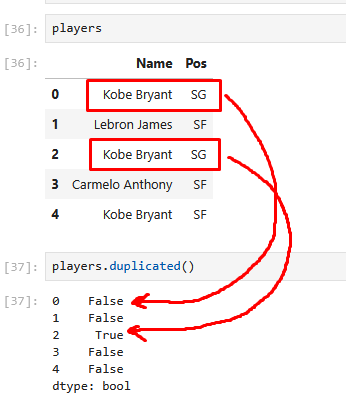

In [36]:
players

,Name,Pos
0,Kobe Bryant,SG
1,Lebron James,SF
2,Kobe Bryant,SG
3,Carmelo Anthony,SF
4,Kobe Bryant,SF


In [37]:
players.duplicated()

0    False
1    False
2     True
3    False
4    False
dtype: bool

Otra vez conceptualmente se considera duplicado cuando todos los valores de la fila estan duplicados. Esto se puede personalizar con el parámetros **subset**

**duplicated(subset=['Name']):** 

En este caso solo verifica los duplicados de la columna 'Name' y la primera ocurrencia no la cuenta como duplicado

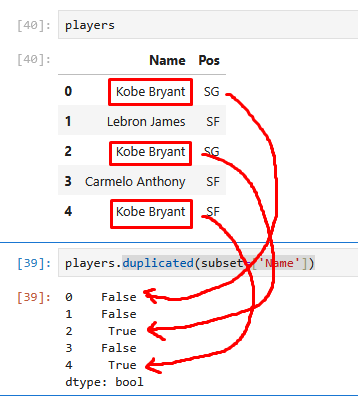

In [40]:
players

,Name,Pos
0,Kobe Bryant,SG
1,Lebron James,SF
2,Kobe Bryant,SG
3,Carmelo Anthony,SF
4,Kobe Bryant,SF


In [41]:
players.duplicated(subset=['Name'])

0    False
1    False
2     True
3    False
4     True
dtype: bool

**drop_duplicates(subset = ['Name'], keep = 'last')**

Elimina todos los duplicados de la columna 'Name' y solo mantiene la última

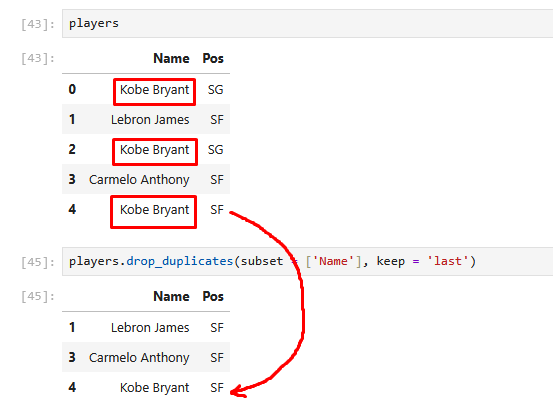

In [43]:
players

,Name,Pos
0,Kobe Bryant,SG
1,Lebron James,SF
2,Kobe Bryant,SG
3,Carmelo Anthony,SF
4,Kobe Bryant,SF


In [45]:
players.drop_duplicates(subset = ['Name'], keep = 'last')

,Name,Pos
1,Lebron James,SF
3,Carmelo Anthony,SF
4,Kobe Bryant,SF


# Manejo de Texto

El manejo de valores de texto puede ser increiblemente dificil. Los valores de texto no validos implican, en el 99% de los casos errores tipográficos, lo cual es completamente impredecible y no sigue ningún patron. Afortunadamente no es tan común hoy en día, donde las tareas de entrada de datos han sido reemplazadas por maquinas. Aún asi, exploremos los casos mas comunes 

### División de columnas

El resultado de una encuesta esta cargado en este DataFrame

In [46]:
df = pd.DataFrame({
    'Data': [
        '1987_M_US _1',
        '1990?_M_UK_1',
        '1992_F_US_2',
        '1970?_M_    IT_1',
        '1985_F_I   T_2'
    ]
})

In [47]:
df

,Data
0,1987_M_US _1
1,1990?_M_UK_1
2,1992_F_US_2
3,1970?_M_ IT_1
4,1985_F_I T_2


Sabes que una simple columna representa los valores "year, Sex, Country and number of children", pero todos estan agrupados en la misma columna y separados por raya baja. Pandas tiene un método conveniente llamado **split** que podemos utilizar en estas situaciones

- La función **str()** convierte los datos a *string*

In [49]:
df['Data'].str.split("_")

0        [1987, M, US , 1]
1        [1990?, M, UK, 1]
2         [1992, F, US, 2]
3    [1970?, M,     IT, 1]
4      [1985, F, I   T, 2]
Name: Data, dtype: object

**str.split("_", expand = True)** Expand = True lo que hace es crear un ***DataFrame***

In [50]:
df['Data'].str.split("_", expand = True)

,0,1,2,3
0,1987,M,US,1
1,1990?,M,UK,1
2,1992,F,US,2
3,1970?,M,IT,1
4,1985,F,I T,2
